# Tag 09 - Anfänger
## Random Forest vs. Single Tree - Wine Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
OUTPUT_SUBDIR = "01_anfaenger"

In [2]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
PROJECT_DIR = None
for p in [START, *START.parents]:
    if (p / "data" / "raw").exists() and (p / "outputs").exists():
        PROJECT_DIR = p
        break
if PROJECT_DIR is None:
    PROJECT_DIR = Path(r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_09_Ensemble_Methods_Project")
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_SUBDIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_09_Ensemble_Methods_Project
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_09_Ensemble_Methods_Project\data\raw
OUTPUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_09_Ensemble_Methods_Project\outputs\01_anfaenger


In [3]:
possible_files = [
    "winequality-red.csv",
    "winequality-white.csv",
    "WineQT.csv",
    "wine_quality.csv",
    "Wine_Quality.csv",
    "wine.csv"
]

DATA_PATH = None
for name in possible_files:
    candidate = DATA_DIR / name
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(f"Put a Wine Quality file in {DATA_DIR}. Accepted names: {possible_files}")

print("Using file:", DATA_PATH)

try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df = pd.read_csv(DATA_PATH, sep=";")
except UnicodeDecodeError:
    df = pd.read_csv(DATA_PATH, encoding="latin1")
    if df.shape[1] == 1:
        df = pd.read_csv(DATA_PATH, sep=";", encoding="latin1")

df.columns = df.columns.str.strip()
print(df.shape)
df.head()

Using file: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_09_Ensemble_Methods_Project\data\raw\winequality-red.csv
(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
if "quality" not in df.columns:
    raise ValueError(f"Target column 'quality' not found. Available columns: {df.columns.tolist()}")

df = df.dropna().copy()

X = df.drop(columns=["quality"])
y = df["quality"]

X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Classes:", sorted(y.unique()))

X_train: (1279, 11)
X_test: (320, 11)
Classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [5]:
single_tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
random_forest = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

single_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

models = {
    "DecisionTree": single_tree,
    "RandomForest_100": random_forest
}

rows = []
for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    rows.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

accuracy_df = pd.DataFrame(rows)
accuracy_df.to_csv(OUTPUT_DIR / "beginner_model_accuracy.csv", index=False)
accuracy_df

,model,train_accuracy,test_accuracy
0,DecisionTree,1.0,0.606250
1,RandomForest_100,1.0,0.678125


c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



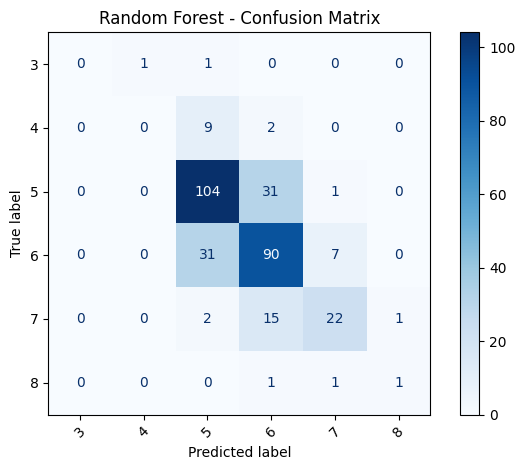

In [6]:
y_pred_rf = random_forest.predict(X_test)
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=random_forest.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_forest.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_random_forest_confusion_matrix.png", dpi=200)
plt.show()

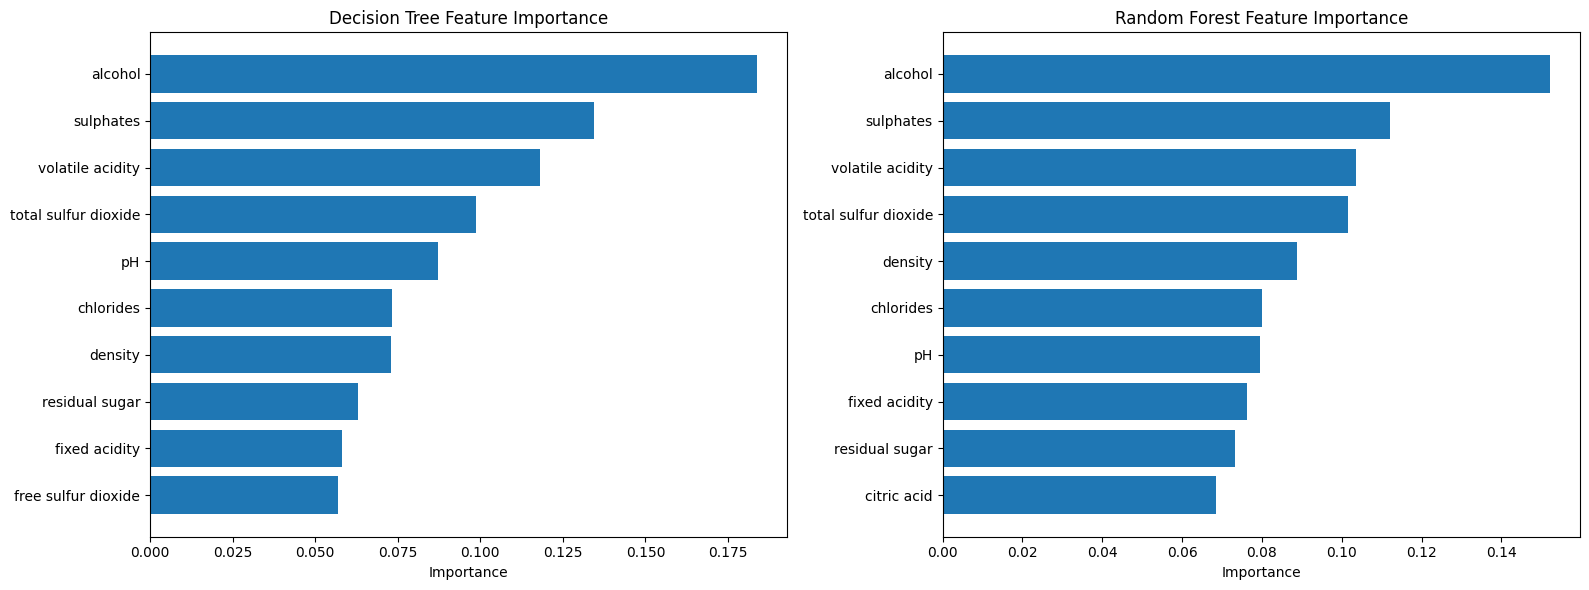

In [7]:
tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": single_tree.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": random_forest.feature_importances_
}).sort_values("importance", ascending=False)

tree_importance.to_csv(OUTPUT_DIR / "beginner_decision_tree_feature_importance.csv", index=False)
rf_importance.to_csv(OUTPUT_DIR / "beginner_random_forest_feature_importance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tree_top = tree_importance.head(10).iloc[::-1]
rf_top = rf_importance.head(10).iloc[::-1]

axes[0].barh(tree_top["feature"], tree_top["importance"])
axes[0].set_title("Decision Tree Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(rf_top["feature"], rf_top["importance"])
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_feature_importance_tree_vs_rf.png", dpi=200)
plt.show()

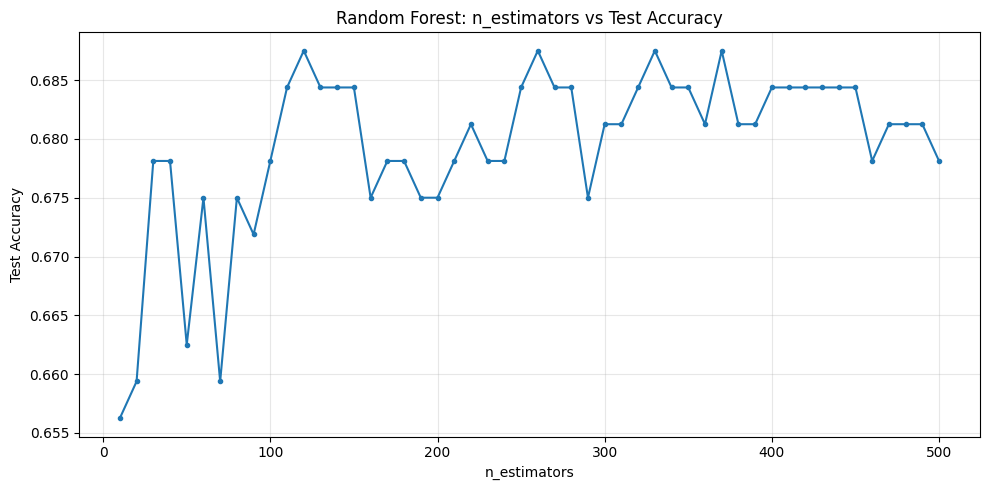

,n_estimators,test_accuracy
45,460,0.678125
46,470,0.681250
47,480,0.681250
48,490,0.681250
49,500,0.678125


In [8]:
results = []
for n in range(10, 501, 10):
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "n_estimators": n,
        "test_accuracy": accuracy_score(y_test, pred)
    })

n_estimators_df = pd.DataFrame(results)
n_estimators_df.to_csv(OUTPUT_DIR / "beginner_n_estimators_accuracy.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_df["n_estimators"], n_estimators_df["test_accuracy"], marker="o", markersize=3)
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: n_estimators vs Test Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "beginner_n_estimators_accuracy_curve.png", dpi=200)
plt.show()

n_estimators_df.tail()